In [1]:
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from rose.data import training_data
from rose.optimize import plot_hyperparameter_trials_3d, plot_numeric_hyperparameter
from rose.viz import plot_response_surface, plot_response_surface_matplotlib

hyperparams = [
    "max_iter",
    "learning_rate",
    "max_leaf_nodes",
    "max_depth",
    "min_samples_leaf",
    "l2_regularization",
    "max_bins",
]
log_hyperparameters = {"learning_rate", "l2_regularization"}

X_train, y_train = training_data(N=1000, seed=37)
X_test, y_test = training_data(N=1000, seed=42)

In [2]:
def objective(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 63),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100),
        "l2_regularization": trial.suggest_float(
            "l2_regularization", 1e-8, 10.0, log=True
        ),
        "max_bins": trial.suggest_int("max_bins", 16, 255),
        "random_state": 37,
    }

    model = HistGradientBoostingRegressor(**cast(dict[str, Any], params))
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = mse**0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    miscalibration = y_pred.mean() - y_test.mean()
    accuracy = np.mean(y_test == np.rint(y_pred))

    trial.set_user_attr("mse", mse)
    trial.set_user_attr("rmse", rmse)
    trial.set_user_attr("mae", mae)
    trial.set_user_attr("r2", r2)
    trial.set_user_attr("miscalibration", miscalibration)
    trial.set_user_attr("accuracy", accuracy)

    return mse


sampler = optuna.samplers.TPESampler(seed=37)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best MSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-25 19:45:20,437] A new study created in memory with name: no-name-68a94742-ca16-4191-8564-ee418aeee816


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-25 19:45:22,811] Trial 0 finished with value: 0.032617790752185585 and parameters: {'max_iter': 1895, 'learning_rate': 0.02770021382056352, 'max_leaf_nodes': 14, 'max_depth': 8, 'min_samples_leaf': 64, 'l2_regularization': 0.014388521072426656, 'max_bins': 40}. Best is trial 0 with value: 0.032617790752185585.
[I 2026-05-25 19:45:23,645] Trial 1 finished with value: 0.07241858563548269 and parameters: {'max_iter': 1517, 'learning_rate': 0.014148727780206545, 'max_leaf_nodes': 48, 'max_depth': 10, 'min_samples_leaf': 65, 'l2_regularization': 9.803916280979927e-05, 'max_bins': 247}. Best is trial 0 with value: 0.032617790752185585.
[I 2026-05-25 19:45:24,506] Trial 2 finished with value: 0.12560671870426163 and parameters: {'max_iter': 1805, 'learning_rate': 0.010333853024112882, 'max_leaf_nodes': 39, 'max_depth': 8, 'min_samples_leaf': 72, 'l2_regularization': 2.30865036345865, 'max_bins': 28}. Best is trial 0 with value: 0.032617790752185585.
[I 2026-05-25 19:45:24,630] Tria

In [3]:
rows = []

for t in study.trials:
    row = {
        "trial": t.number,
        "target_mse": t.value,
    }
    row.update({str(key): value for key, value in t.params.items()})
    row.update({str(key): value for key, value in t.user_attrs.items()})
    rows.append(row)

trials_df = pd.DataFrame(rows).sort_values("target_mse").reset_index(drop=True)

pd.set_option("display.max_rows", None)
trials_df

,trial,target_mse,max_iter,learning_rate,max_leaf_nodes,max_depth,min_samples_leaf,l2_regularization,max_bins,mse,rmse,mae,r2,miscalibration,accuracy
0,11,0.000016,1268,0.163793,3,2,6,1.533541e-08,93,0.000016,0.004047,0.001996,0.999999,0.000424,1.000
1,95,0.000062,991,0.146981,3,2,9,5.108577e-07,130,0.000062,0.007890,0.004351,0.999995,0.000088,1.000
2,47,0.000065,1776,0.071482,3,2,42,6.426297e-07,176,0.000065,0.008081,0.004900,0.999994,0.000428,1.000
3,61,0.000072,1089,0.114538,3,2,25,3.307574e-06,239,0.000072,0.008495,0.005416,0.999994,0.000738,1.000
4,51,0.000074,1710,0.071060,3,2,36,1.241291e-07,79,0.000074,0.008588,0.005429,0.999994,0.000421,1.000
5,58,0.000089,1031,0.128973,3,3,17,3.018263e-06,228,0.000089,0.009424,0.005667,0.999992,0.000415,1.000
6,63,0.000122,866,0.133078,3,2,25,8.038764e-07,173,0.000122,0.011051,0.006993,0.999990,0.000497,1.000
7,41,0.000123,1388,0.082359,3,2,8,2.303658e-06,29,0.000123,0.011081,0.007208,0.999989,0.000717,1.000
8,23,0.000125,1384,0.080015,3,2,14,4.528856e-05,111,0.000125,0.011202,0.007461,0.999989,0.000705,1.000
9,81,0.000133,947,0.108622,3,3,12,6.609610e-06,126,0.000133,0.011526,0.007501,0.999989,0.000827,1.000


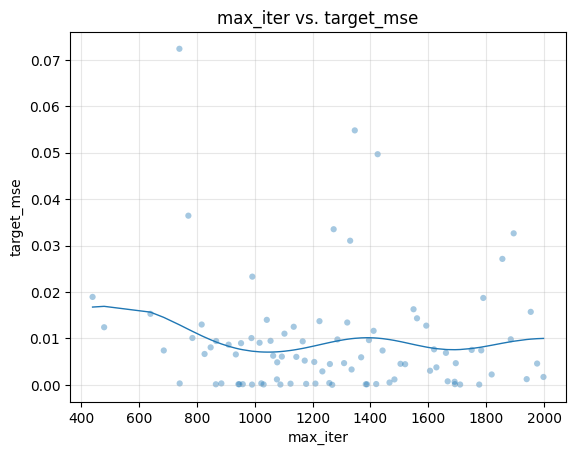

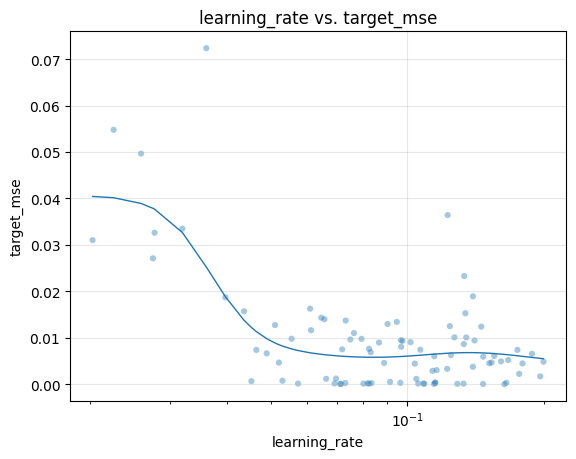

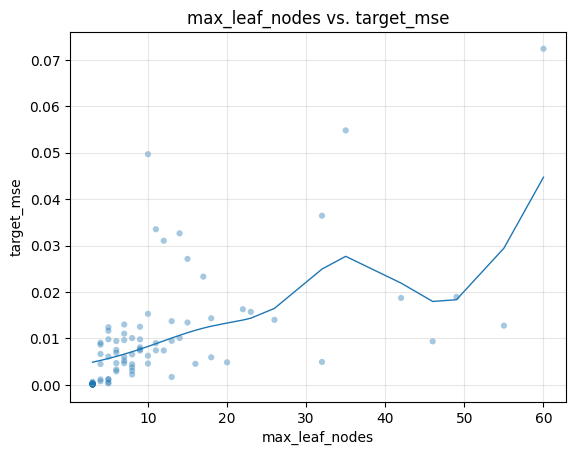

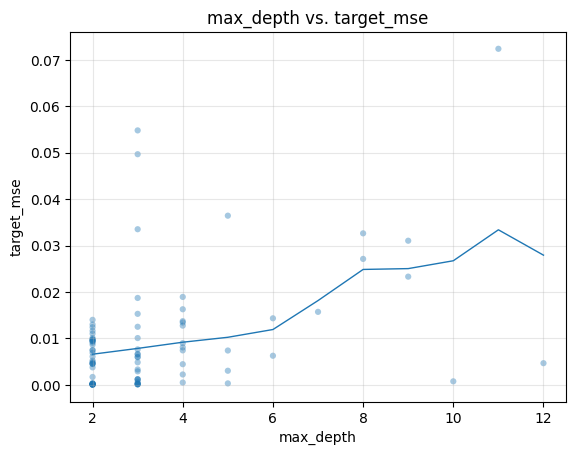

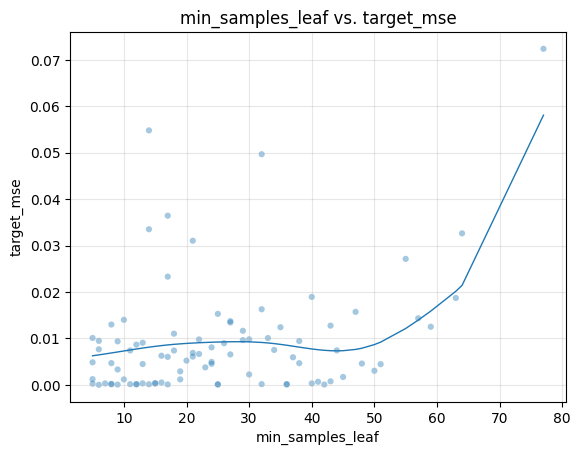

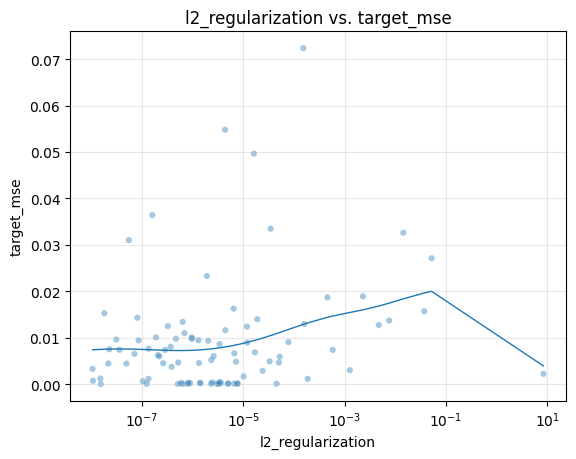

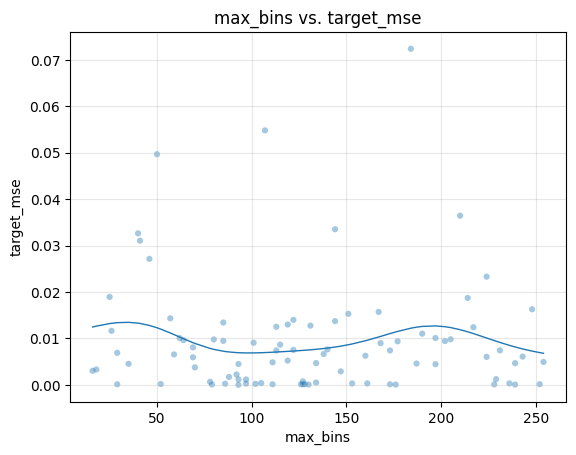

In [4]:
for hyperparameter in hyperparams:
    plot_numeric_hyperparameter(
        trials_df,
        hyperparameter,
        target="target_mse",
        log_x=(hyperparameter in log_hyperparameters),
        bandwidth_fraction=0.10,
    )

Best hyperparameters: {'max_iter': 1268, 'learning_rate': 0.16379302966980017, 'max_leaf_nodes': 3, 'max_depth': 2, 'min_samples_leaf': 6, 'l2_regularization': 1.5335407616629294e-08, 'max_bins': 93}
MAE: 0.00580467491264203
RMSE: 0.008050942839042296
R2: 0.9999944500544742
miscalibration: 0.000


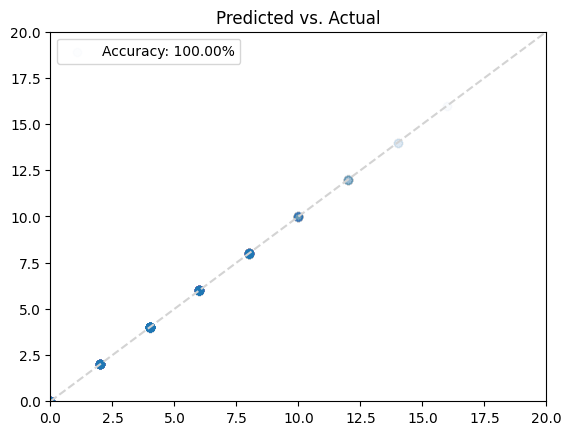

In [5]:
def train_best_model(N):
    X_train, y_train = training_data(N=N, seed=37)
    X_test, y_test = training_data(N=1000, seed=42)

    best_params = (
        trials_df.sort_values("target_mse", ascending=True)
        .iloc[0][hyperparams]
        .to_dict()
    )

    # Cast integer-valued hyperparameters back to int
    for hp in [
        "max_iter",
        "max_leaf_nodes",
        "max_depth",
        "min_samples_leaf",
        "max_bins",
    ]:
        if hp in best_params and not pd.isna(best_params[hp]):
            best_params[hp] = int(best_params[hp])

    # Drop NaNs, e.g. max_depth=None if it was not used
    best_params = {k: v for k, v in best_params.items() if not pd.isna(v)}

    model = HistGradientBoostingRegressor(
        **cast(dict[str, Any], best_params), random_state=37
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Best hyperparameters:", best_params)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))
    print(f"miscalibration: {y_pred.mean() - y_test.mean():0.3f}")

    accuracy = np.mean(y_test == np.rint(y_pred))

    plt.title("Predicted vs. Actual")
    plt.ylim(0, 20)
    plt.xlim(0, 20)
    plt.scatter(y_test, y_pred, alpha=10 / len(y_test))
    plt.plot([0, 20], [0, 20], linestyle="--", color="lightgray")
    plt.legend([f"Accuracy: {accuracy * 100:.2f}%"])

    return model


model = train_best_model(N=250)

In [6]:
(trials_df.sort_values("target_mse", ascending=True).iloc[0][hyperparams].to_dict())

{'max_iter': 1268.0,
 'learning_rate': 0.16379302966980017,
 'max_leaf_nodes': 3.0,
 'max_depth': 2.0,
 'min_samples_leaf': 6.0,
 'l2_regularization': 1.5335407616629294e-08,
 'max_bins': 93.0}

In [10]:
for i in range(1, 7):
    y_hat = round(model.predict(np.array([[i, i, i, i, i]])).item(0) / 5, 1)
    y_hat_display = 0.0 if round(y_hat, 1) == 0 else y_hat
    print(f"Die #{i + 1} Prediction: {y_hat_display:0.1f}")

Die #2 Prediction: 0.0
Die #3 Prediction: 0.0
Die #4 Prediction: 2.0
Die #5 Prediction: 0.0
Die #6 Prediction: 4.0
Die #7 Prediction: 0.0


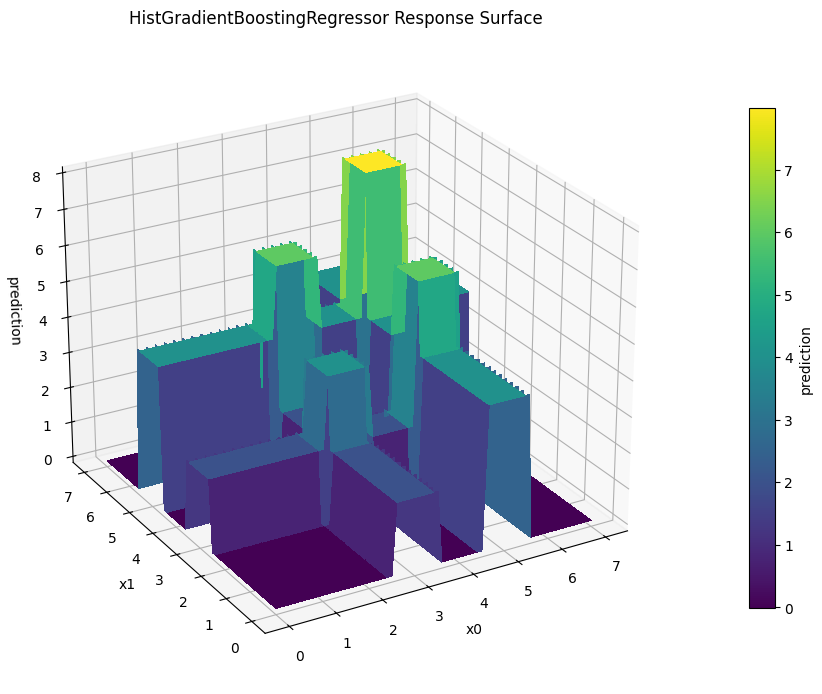

In [ ]:
plot_response_surface_matplotlib(
    model,
    feature_count=5,
    fixed_values=(1, 1, 1),
    x_index=0,
    y_index=1,
    title="HistGradientBoostingRegressor Response Surface",
)

In [ ]:
param_importances = optuna.importance.get_param_importances(
    study,
    target=lambda trial: trial.value,
)

top_numeric_hyperparameters = [
    name for name in param_importances if name in hyperparams
][:2]

plot_hyperparameter_trials_3d(
    trials_df,
    top_numeric_hyperparameters[0],
    top_numeric_hyperparameters[1],
    target="target_mse",
    title="Tree Hyperparameter Trials",
)

In [ ]:
# import plotly.io as pio
# pio.renderers.default = "vscode" # VS Code
# pio.renderers.default = "iframe" # Jupyter Lab

In [ ]:
plot_response_surface(
    model,
    feature_count=5,
    fixed_values=(1, 1, 1),
    x_index=0,
    y_index=1,
    title="HistGradientBoostingRegressor Response Surface",
    colorscale="Viridis",
)